In [1]:
"""
# 14. Grad-CAM e Interpretabilidad

## Objetivos
- Entender qué regiones de la imagen activa el modelo para predecir
- Implementar "Grad-CAM" desde cero con Keras 3
- Aplicarlo sobre EfficientNetB0 (mejor modelo, 93.1%)
- Analizar si el modelo aprende features semánticamente relevantes
- Comparar mapas de activación entre clases correctas e incorrectas

## ¿Por qué interpretabilidad?
Un modelo con 93% de accuracy puede estar acertando por las razones equivocadas — por ejemplo, clasificar "ship"
por el color azul del agua en lugar de la forma del barco.
Grad-CAM nos permite verificarlo visualmente.
## Grad-CAM (Gradient-weighted Class Activation Mapping)

Grad-CAM responde la pregunta:
"¿qué partes de la imagen llevaron al modelo a esta predicción?"

### ¿Cómo funciona?
1. Se hace un forward pass con la imagen
2. Se toman los "gradientes" de la clase predicha respecto a los "feature maps" de la última capa convolucional
3. Se promedian esos gradientes por canal → pesos de importancia
4. Se combinan los feature maps pesados → mapa de calor
5. Se aplica ReLU (solo activaciones positivas) y se superpone sobre la imagen original

### ¿Por qué la última capa conv?
Es donde la red tiene la representación más abstracta y espacialmente localizada — combina semántica (qué) con ubicación (dónde).

"
Input → [conv layers] → [última conv] → [GAP] → [Dense] → predicción
                              ↑
                         Grad-CAM actúa aquí
"
"""

'\n# 14. Grad-CAM e Interpretabilidad\n\n## Objetivos\n- Entender qué regiones de la imagen activa el modelo para predecir\n- Implementar "Grad-CAM" desde cero con Keras 3\n- Aplicarlo sobre EfficientNetB0 (mejor modelo, 93.1%)\n- Analizar si el modelo aprende features semánticamente relevantes\n- Comparar mapas de activación entre clases correctas e incorrectas\n\n## ¿Por qué interpretabilidad?\nUn modelo con 93% de accuracy puede estar acertando por las razones equivocadas — por ejemplo, clasificar "ship"\npor el color azul del agua en lugar de la forma del barco.\nGrad-CAM nos permite verificarlo visualmente.\n## Grad-CAM (Gradient-weighted Class Activation Mapping)\n\nGrad-CAM responde la pregunta:\n"¿qué partes de la imagen llevaron al modelo a esta predicción?"\n\n### ¿Cómo funciona?\n1. Se hace un forward pass con la imagen\n2. Se toman los "gradientes" de la clase predicha respecto a los "feature maps" de la última capa convolucional\n3. Se promedian esos gradientes por canal →

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import cv2

tf.random.set_seed(42)
np.random.seed(42)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")

TensorFlow version: 2.21.0
Keras version:      3.14.0


In [3]:
# Cargamos EfficientNetB0 — mejor modelo (93.1%)
model = keras.models.load_model("../models/12_efficientnetb0_finetuned.keras")

print("Modelo cargado ✓")

# CIFAR-10
(_, _), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_test = x_test.astype("float32") / 255.0
y_test = y_test.flatten()

print(f"Test set: {x_test.shape}")

Modelo cargado ✓


C:\Users\Peter\ml_env\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Test set: (10000, 32, 32, 3)


In [15]:
# Necesitamos el nombre exacto de la última capa conv de EfficientNetB0
# para construir el modelo Grad-CAM

# Listar las últimas 10 capas
for layer in model.layers[-10:]:
    print(f"{layer.name:<50} {layer.__class__.__name__}")

input_layer_1                                      InputLayer
efficientnetb0                                     Functional
global_average_pooling2d                           GlobalAveragePooling2D
dense                                              Dense
dropout                                            Dropout
dense_1                                            Dense


In [24]:
"""
## Implementación de Grad-CAM en Keras 3

Necesitamos un modelo intermedio que exponga:
- Los "feature maps" de la última capa convolucional
- La "predicción final"

Luego usamos "tf.GradientTape" para calcular los gradientes de la clase predicha respecto a esos feature maps.
"""
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    base = model.get_layer("efficientnetb0")

    # Modelo interno: input de la base → top_conv + output final
    inner_model = keras.models.Model(
        inputs=base.input,
        outputs=[
            base.get_layer(last_conv_layer_name).output,
            base.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, base_out = inner_model(img_array)
        # Pasar base_out por el resto del modelo (GAP → Dense → Dropout → Dense)
        x = model.get_layer("global_average_pooling2d")(base_out)
        x = model.get_layer("dense")(x)
        x = model.get_layer("dropout")(x, training=False)
        predictions = model.get_layer("dense_1")(x)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads        = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.nn.relu(heatmap)
    heatmap      = heatmap / (tf.math.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

print("make_gradcam_heatmap actualizada ✓")

make_gradcam_heatmap actualizada ✓


In [20]:
IMG_SIZE = 96

def preprocess_for_gradcam(img):
    """
    Preprocesa una imagen de CIFAR-10 para EfficientNetB0.
    Retorna el tensor con batch dim y la imagen resizada para visualización.
    """
    # Imagen para visualizar (resizada, sin preprocess_input)
    img_display = cv2.resize(
        np.uint8(img * 255), (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_LINEAR
    ).astype("float32") / 255.0

    # Tensor para el modelo
    img_tensor = tf.image.resize(
        tf.cast(img * 255.0, tf.float32)[tf.newaxis],
        (IMG_SIZE, IMG_SIZE)
    )
    img_tensor = keras.applications.efficientnet.preprocess_input(img_tensor)

    return img_tensor, img_display

print("Pipeline Grad-CAM listo ✓")

Pipeline Grad-CAM listo ✓


In [18]:
def plot_gradcam_grid(indices, y_true, title=""):
    """
    Muestra imagen original + heatmap + superposición para una lista de índices.
    """
    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(10, 3.5 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(indices):
        img      = x_test[idx]
        true_cls = CLASS_NAMES[y_true[idx]]

        img_tensor, img_display = preprocess_for_gradcam(img)

        # Predicción
        preds     = model.predict(img_tensor, verbose=0)
        pred_idx  = np.argmax(preds[0])
        pred_cls  = CLASS_NAMES[pred_idx]
        conf      = preds[0][pred_idx]

        # Grad-CAM
        heatmap   = make_gradcam_heatmap(img_tensor, model, last_conv_layer_name)
        overlay   = overlay_gradcam(img_display, heatmap)

        # Plots
        axes[row, 0].imshow(img_display)
        axes[row, 0].set_title(f"Original\nReal: {true_cls}", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(heatmap, cmap="jet")
        axes[row, 1].set_title("Heatmap Grad-CAM", fontsize=9)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(overlay)
        color = "green" if pred_idx == y_true[idx] else "red"
        axes[row, 2].set_title(
            f"Pred: {pred_cls} ({conf:.0%})", fontsize=9, color=color
        )
        axes[row, 2].axis("off")

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    return fig

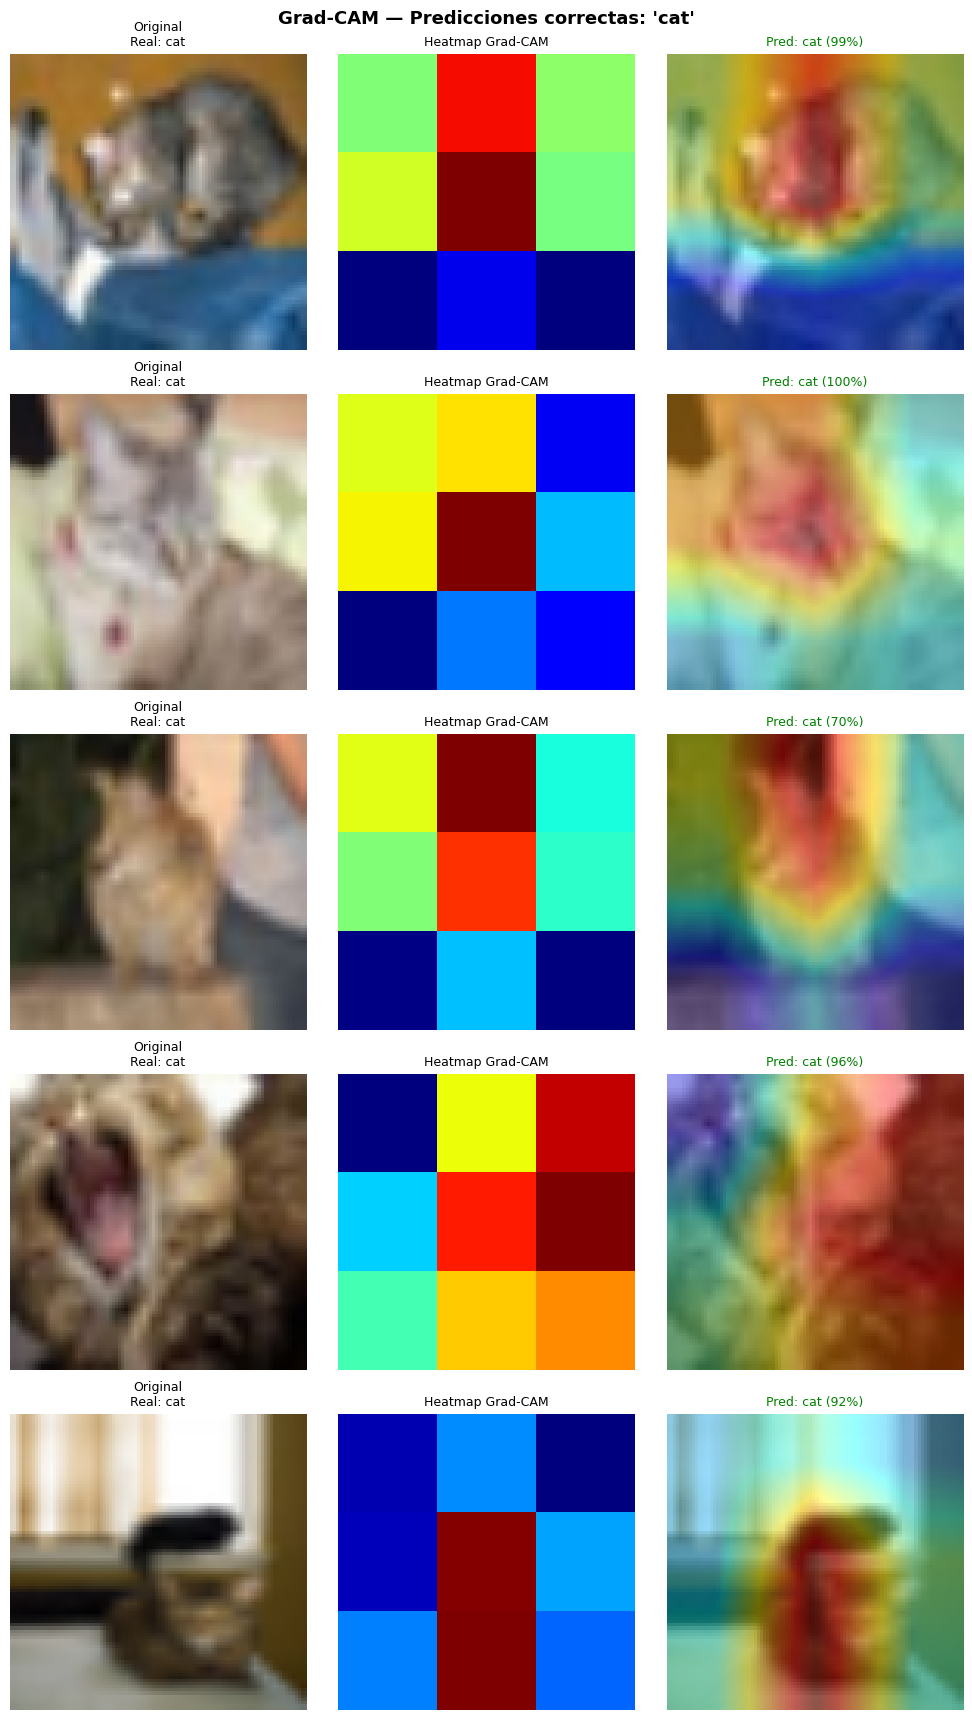

Figura guardada ✓


In [25]:
# 5 ejemplos bien clasificados de cat y dog
correct_cat = np.where((y_test == 3) & 
                        (np.argmax(model.predict(
                            keras.applications.efficientnet.preprocess_input(
                                tf.image.resize(x_test * 255, (IMG_SIZE, IMG_SIZE))
                            ), verbose=0), axis=1) == 3))[0][:5]

fig = plot_gradcam_grid(
    correct_cat[:5], y_test,
    title="Grad-CAM — Predicciones correctas: 'cat'"
)
plt.savefig("../figures/14_gradcam_correct_cat.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada ✓")

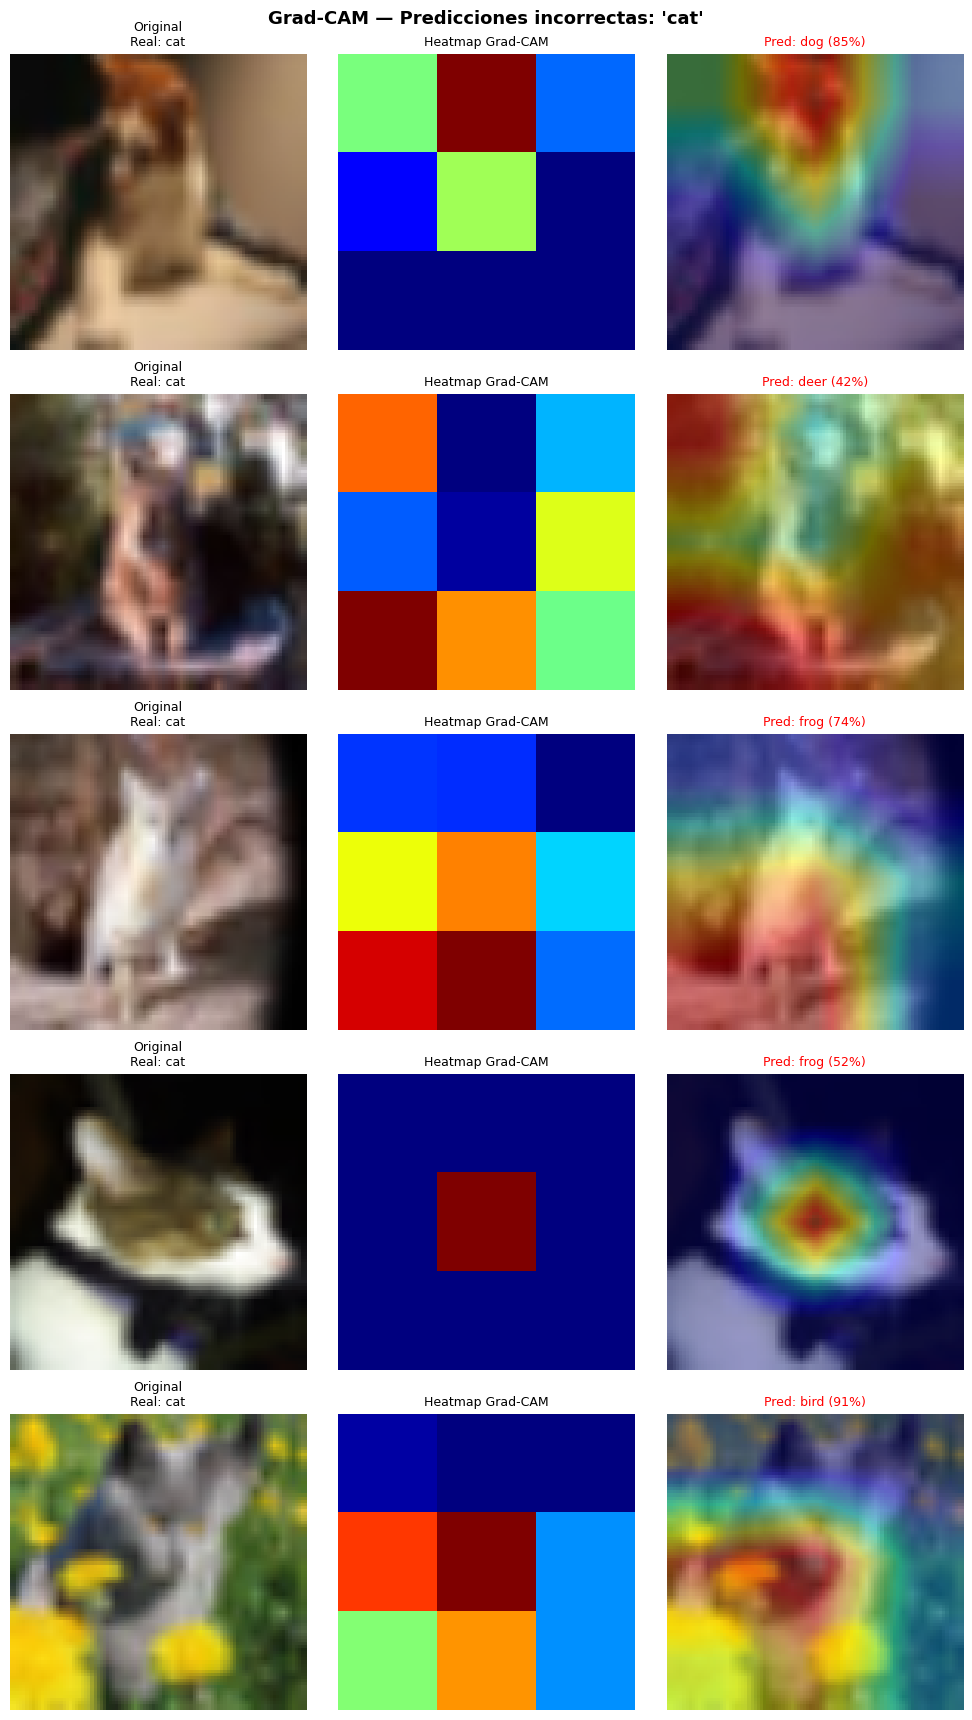

Figura guardada ✓


In [27]:
# 5 ejemplos mal clasificados de cat
incorrect_cat = np.where((y_test == 3) &
                          (np.argmax(model.predict(
                              keras.applications.efficientnet.preprocess_input(
                                  tf.image.resize(x_test * 255, (IMG_SIZE, IMG_SIZE))
                              ), verbose=0), axis=1) != 3))[0][:5]

fig = plot_gradcam_grid(
    incorrect_cat[:5], y_test,
    title="Grad-CAM — Predicciones incorrectas: 'cat'"
)
plt.savefig("../figures/14_gradcam_incorrect_cat.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada ✓")

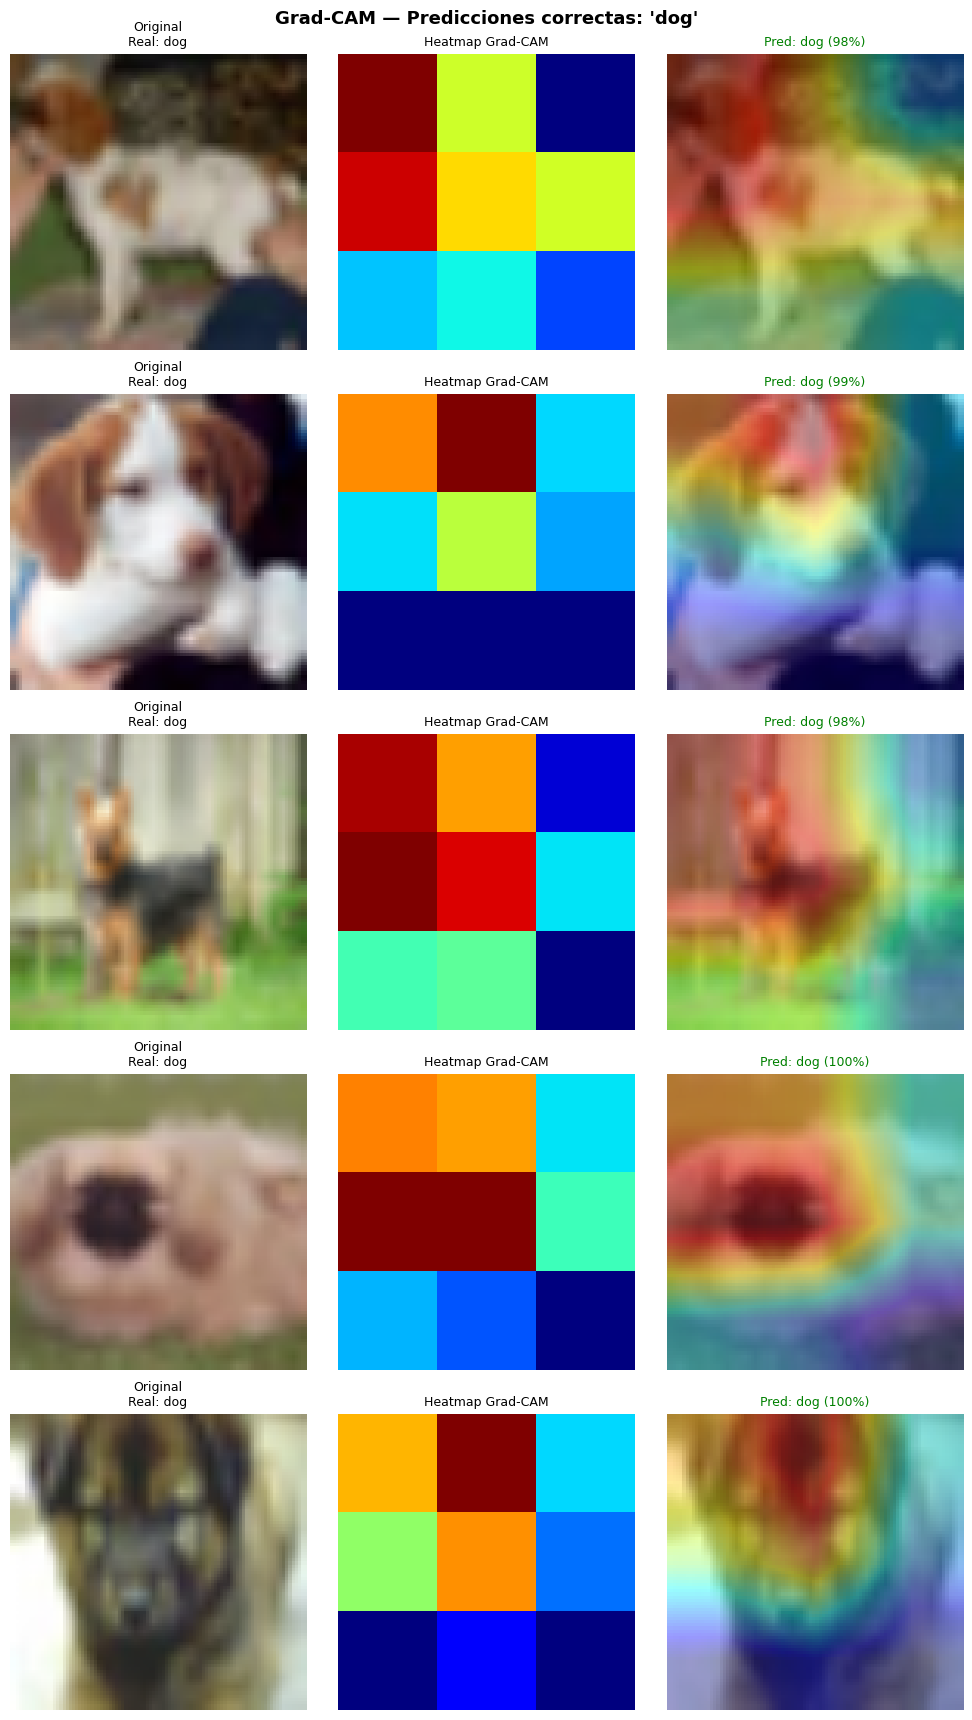

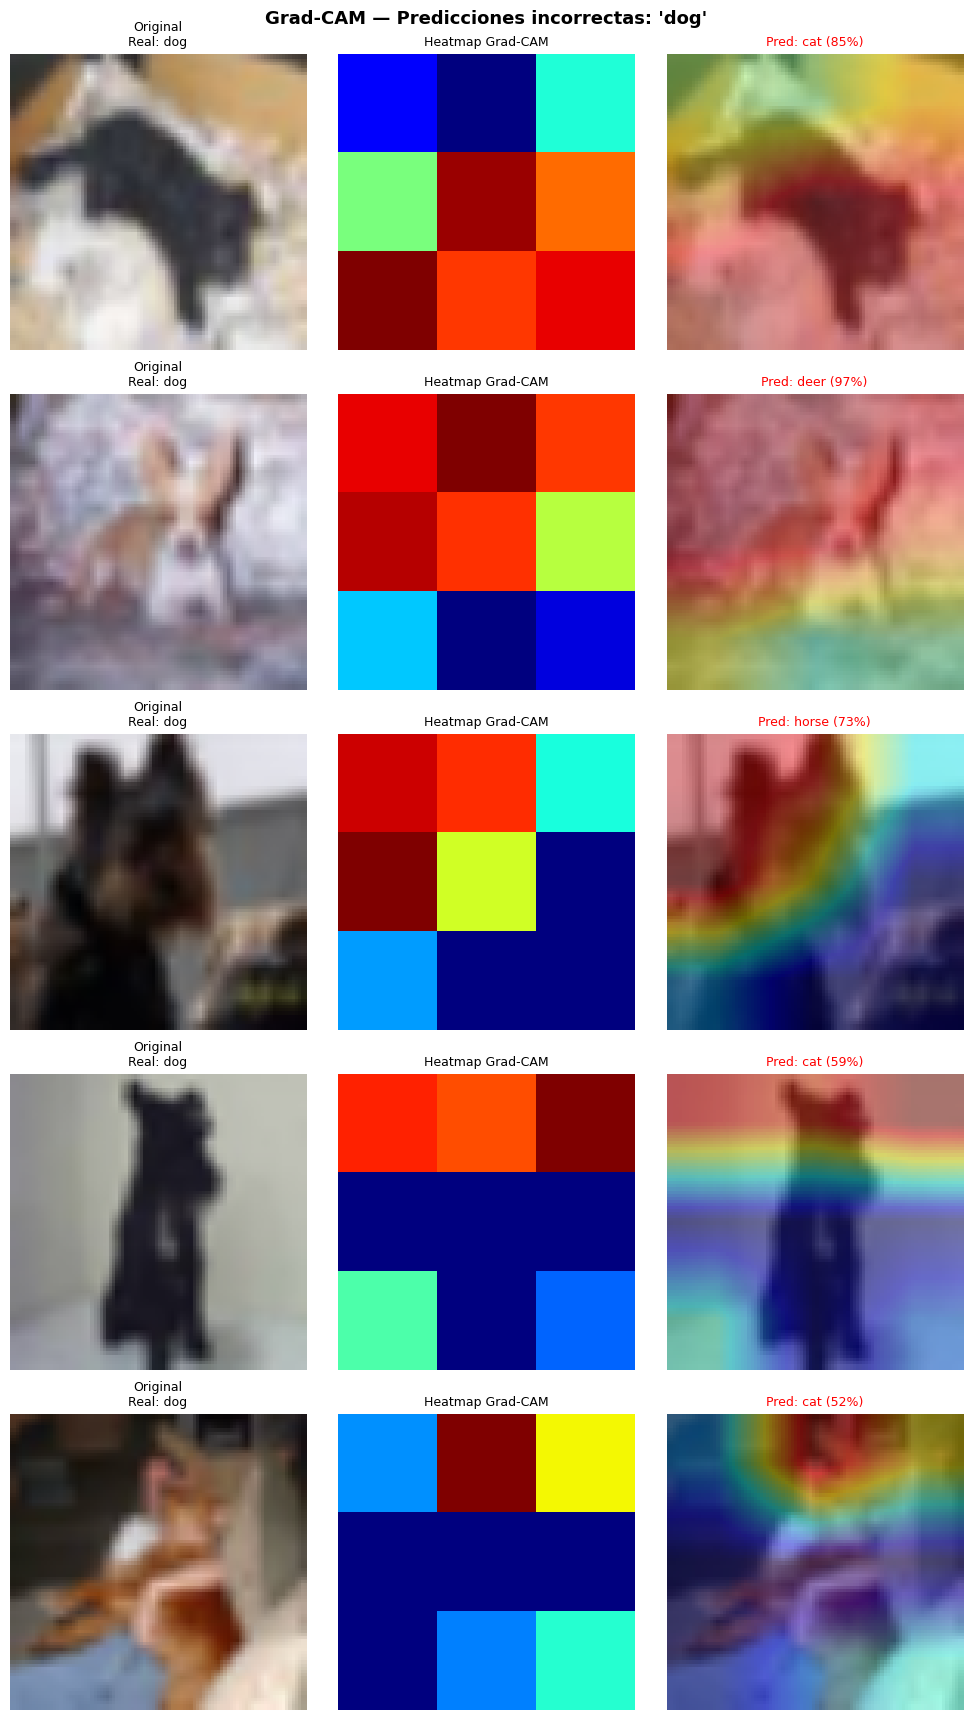

Figuras guardadas ✓


In [28]:
# Correctos dog
correct_dog = np.where((y_test == 5) &
                        (np.argmax(model.predict(
                            keras.applications.efficientnet.preprocess_input(
                                tf.image.resize(x_test * 255, (IMG_SIZE, IMG_SIZE))
                            ), verbose=0), axis=1) == 5))[0][:5]

fig = plot_gradcam_grid(
    correct_dog[:5], y_test,
    title="Grad-CAM — Predicciones correctas: 'dog'"
)
plt.savefig("../figures/14_gradcam_correct_dog.png", dpi=150, bbox_inches="tight")
plt.show()

# Incorrectos dog
incorrect_dog = np.where((y_test == 5) &
                          (np.argmax(model.predict(
                              keras.applications.efficientnet.preprocess_input(
                                  tf.image.resize(x_test * 255, (IMG_SIZE, IMG_SIZE))
                              ), verbose=0), axis=1) != 5))[0][:5]

fig = plot_gradcam_grid(
    incorrect_dog[:5], y_test,
    title="Grad-CAM — Predicciones incorrectas: 'dog'"
)
plt.savefig("../figures/14_gradcam_incorrect_dog.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figuras guardadas ✓")

In [29]:
"""
## Conclusiones

### ¿Qué aprendió el modelo?
Los mapas Grad-CAM muestran que EfficientNetB0 aprendió features semánticamente relevantes:
- En predicciones "correctas": el modelo activa la región del cuerpo y cabeza del animal — está mirando lo correcto.
- En predicciones "incorrectas": el modelo activa zonas ambiguas como el hocico o la postura corporal, que comparten features visuales entre cat, dog y deer.
### ¿Por qué se confunden cat, dog y deer?
- Comparten texturas de pelaje similares
- Poses parecidas (animal acostado, de perfil)
- La resolución de CIFAR-10 (32×32) borra detalles discriminativos como orejas, ojos y proporciones corporales
- El upscaling a 96×96 no recupera información perdida
### ¿El modelo aprende por las razones correctas?
Sí — Grad-CAM confirma que el modelo no está haciendo atajos espurios (como clasificar por el color del fondo).
Los errores son inherentes a la ambigüedad visual del dataset, no a fallas en el aprendizaje.
### Limitación de Grad-CAM en CIFAR-10
El heatmap tiene resolución muy baja (3×3 o 4×4 bloques) porque la última capa conv de EfficientNetB0 produce
feature maps pequeños. En imágenes de mayor resolución los mapas serían más detallados y precisos.
### Próximo notebook
"15_small_dataset_strategy_synthetic_images.ipynb" —
Estrategias para datasets pequeños e imágenes sintéticas.
"""

'\n## Conclusiones\n\n### ¿Qué aprendió el modelo?\nLos mapas Grad-CAM muestran que EfficientNetB0 aprendió features semánticamente relevantes:\n- En predicciones "correctas": el modelo activa la región del cuerpo y cabeza del animal — está mirando lo correcto.\n- En predicciones "incorrectas": el modelo activa zonas ambiguas como el hocico o la postura corporal, que comparten features visuales entre cat, dog y deer.\n### ¿Por qué se confunden cat, dog y deer?\n- Comparten texturas de pelaje similares\n- Poses parecidas (animal acostado, de perfil)\n- La resolución de CIFAR-10 (32×32) borra detalles discriminativos como orejas, ojos y proporciones corporales\n- El upscaling a 96×96 no recupera información perdida\n### ¿El modelo aprende por las razones correctas?\nSí — Grad-CAM confirma que el modelo no está haciendo atajos espurios (como clasificar por el color del fondo).\nLos errores son inherentes a la ambigüedad visual del dataset, no a fallas en el aprendizaje.\n### Limitación de